# 🧮 Notebook 04 — Merge, Feature Engineering & Crisis Score
## Early Warning System Krisis Pariwisata Bali

Notebook ini:
1. Load semua data processed dari notebook sebelumnya
2. Sinkronisasi timeline (semua jadi bulanan)
3. Merge semua dataset menjadi satu final dataset
4. Feature engineering (growth rate, volatility, anomaly score, dll)
5. Hitung Crisis Score komposit berbobot
6. Buat label krisis (low / medium / high)
7. Visualisasi final & simpan dataset final

**Output:** `data/final/crisis_dataset_final.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('data/final', exist_ok=True)

print('✅ Library siap')

✅ Library siap


## 1. Load Semua Data Processed

In [2]:
# Load wisman gabungan
wisman = pd.read_csv('data/processed/wisman_clean.csv')
wisman['month'] = pd.PeriodIndex(wisman['month'], freq='M')
print(f'✅ wisman: {wisman.shape}, dari {wisman["month"].min()} hingga {wisman["month"].max()}')

# Load wisnus
wisnus = pd.read_csv('data/processed/wisnus_clean.csv')
wisnus['month'] = pd.PeriodIndex(wisnus['month'], freq='M')
print(f'✅ wisnus: {wisnus.shape}, dari {wisnus["month"].min()} hingga {wisnus["month"].max()}')

# Load kurs USD/IDR
monthly_usd = pd.read_csv('data/processed/monthly_usd.csv')
monthly_usd['month'] = pd.PeriodIndex(monthly_usd['month'], freq='M')
print(f'✅ monthly_usd: {monthly_usd.shape}')

# Load forex
# monthly_forex = pd.read_csv('data/processed/monthly_forex.csv')
# monthly_forex['month'] = pd.PeriodIndex(monthly_forex['month'], freq='M')
# print(f'✅ monthly_forex: {monthly_forex.shape}')

# Load TPK
tpk = pd.read_csv('data/processed/tpk_clean.csv')
tpk['month'] = pd.PeriodIndex(tpk['month'], freq='M')
print(f'✅ tpk: {tpk.shape}')

# Load inflasi
inflasi = pd.read_csv('data/processed/inflasi_clean.csv')
inflasi['month'] = pd.PeriodIndex(inflasi['month'], freq='M')
print(f'✅ inflasi: {inflasi.shape}')

# Load sentimen
sentiment_stats = pd.read_csv('data/processed/sentiment_stats.csv')
print(f'✅ sentiment_stats: {sentiment_stats.shape}')
print()
print('Semua data berhasil dimuat!')

# Load wisman Bali vs Indonesia tahunan
wisman_indo = pd.read_csv('data/processed/wisman_vs_indonesia_clean.csv')
# Data tahunan — tidak perlu PeriodIndex, join by tahun
print(f'✅ wisman_indo: {wisman_indo.shape}, tahun {wisman_indo["tahun"].min()}-{wisman_indo["tahun"].max()}')


✅ wisman: (192, 3), dari 2009-01 hingga 2024-12
✅ wisnus: (264, 3), dari 2004-01 hingga 2025-12
✅ monthly_usd: (180, 2)
✅ tpk: (315, 4)
✅ inflasi: (204, 3)
✅ sentiment_stats: (1, 5)

Semua data berhasil dimuat!
✅ wisman_indo: (57, 4), tahun 1969-2025


## 2. Sinkronisasi Timeline & Merge Semua Dataset

In [3]:
# Gunakan wisman sebagai backbone timeline (2009-sekarang)
# Karena ini dataset paling lengkap

final_df = wisman[['month', 'wisman']].copy()
print(f'Backbone timeline: {len(final_df)} baris')

# Merge wisnus
final_df = final_df.merge(
    wisnus[['date', 'month', 'wisnus']],
    on='month', how='left'
)

# Merge kurs USD/IDR
final_df = final_df.merge(
    monthly_usd[['month', 'usd_idr_avg']],
    on='month', how='left'
)

# # Merge forex IDR/EUR
# final_df = final_df.merge(
#     monthly_forex[['month', 'idr_eur_rate']],
#     on='month', how='left'
# )

# Merge TPK
final_df = final_df.merge(
    tpk[['date', 'month', 'tpk_bintang', 'tpk_non_bintang']],
    on='month', how='left'
)

# Merge inflasi
final_df = final_df.merge(
    inflasi[['date', 'month', 'inflasi_processed']],
    on='month', how='left'
)


# Merge wisman Bali vs Indonesia (data tahunan — join by tahun)
final_df['tahun'] = final_df['month'].dt.year
final_df = final_df.merge(
    wisman_indo[['tahun', 'indonesia_total', 'bali_share_pct']],
    on='tahun', how='left'
)
final_df.drop(columns=['tahun'], inplace=True)

# Tambahkan sentimen sebagai nilai global (karena tidak ada tanggal di review)
avg_sentiment = sentiment_stats['avg_sentiment'].values[0]
pct_negative = sentiment_stats['pct_negative'].values[0]
final_df['avg_sentiment_global'] = avg_sentiment
final_df['pct_negative_global'] = pct_negative

print(f'Shape setelah merge: {final_df.shape}')
print()
print('Missing values per kolom:')
print(final_df.isnull().sum().to_string())
print()
final_df.head(5)

Backbone timeline: 192 baris
Shape setelah merge: (192, 14)

Missing values per kolom:
month                    0
wisman                   0
date_x                   0
wisnus                   0
usd_idr_avg             12
date_y                   0
tpk_bintang              0
tpk_non_bintang         60
date                     0
inflasi_processed        0
indonesia_total          0
bali_share_pct           0
avg_sentiment_global     0
pct_negative_global      0



,month,wisman,date_x,wisnus,usd_idr_avg,date_y,tpk_bintang,tpk_non_bintang,date,inflasi_processed,indonesia_total,bali_share_pct,avg_sentiment_global,pct_negative_global
0,2009-01,174541,2009-01-01,264915.0,NaN,2009-01-01,47.254,29.32,2009-01-01,9.17,6323730,37.72,0.227519,29.205946
1,2009-02,147704,2009-02-01,204419.0,NaN,2009-02-01,44.210,24.35,2009-02-01,8.60,6323730,37.72,0.227519,29.205946
2,2009-03,168205,2009-03-01,255203.0,NaN,2009-03-01,48.350,32.27,2009-03-01,7.92,6323730,37.72,0.227519,29.205946
3,2009-04,188776,2009-04-01,247100.0,NaN,2009-04-01,53.426,33.41,2009-04-01,7.31,6323730,37.72,0.227519,29.205946
4,2009-05,190803,2009-05-01,289635.0,NaN,2009-05-01,55.382,33.74,2009-05-01,6.04,6323730,37.72,0.227519,29.205946


In [4]:
# Handle missing values
# Forward fill untuk kurs dan TPK (jika ada gap)
# cols_to_ffill = ['usd_idr_avg', 'idr_eur_rate', 'tpk_avg', 'inflasi_bali', 'bali_share_pct', 'indonesia_total']
cols_to_ffill = ['usd_idr_avg', 'tpk_bintang', 'tpk_non_bintang', 
                 'inflasi_processed', 'bali_share_pct', 'indonesia_total']
for col in cols_to_ffill:
    if col in final_df.columns:
        before = final_df[col].isnull().sum()
        final_df[col] = final_df[col].ffill().bfill()
        after = final_df[col].isnull().sum()
        print(f'  {col}: {before} -> {after} missing')

# Wisnus: isi dengan interpolasi
if 'wisnus' in final_df.columns:
    final_df['wisnus'] = final_df['wisnus'].interpolate(method='linear')

print('\nMissing values setelah handle:')
print(final_df.isnull().sum().to_string())

  usd_idr_avg: 12 -> 0 missing
  tpk_bintang: 0 -> 0 missing
  tpk_non_bintang: 60 -> 0 missing
  inflasi_processed: 0 -> 0 missing
  bali_share_pct: 0 -> 0 missing
  indonesia_total: 0 -> 0 missing

Missing values setelah handle:
month                   0
wisman                  0
date_x                  0
wisnus                  0
usd_idr_avg             0
date_y                  0
tpk_bintang             0
tpk_non_bintang         0
date                    0
inflasi_processed       0
indonesia_total         0
bali_share_pct          0
avg_sentiment_global    0
pct_negative_global     0


## 3. Feature Engineering

In [5]:
# ============================================================
# FEATURE ENGINEERING — Buat fitur-fitur untuk model early warning
# ============================================================

# ✅ FIX: Inisialisasi new_features di awal agar bisa diappend di setiap langkah
new_features = []

# 1. Growth rate wisatawan (persentase perubahan month-over-month)
final_df['wisman_growth_mom'] = final_df['wisman'].pct_change()
final_df['wisnus_growth_mom'] = final_df['wisnus'].pct_change() if 'wisnus' in final_df.columns else 0
new_features += ['wisman_growth_mom', 'wisnus_growth_mom']

# 2. Growth rate wisatawan Year-over-Year (12 bulan)
final_df['wisman_growth_yoy'] = final_df['wisman'].pct_change(periods=12)
new_features.append('wisman_growth_yoy')

# 3. Rolling average 3 bulan dan 6 bulan
final_df['wisman_ma3'] = final_df['wisman'].rolling(3).mean()
final_df['wisman_ma6'] = final_df['wisman'].rolling(6).mean()
new_features += ['wisman_ma3', 'wisman_ma6']

# 4. Volatilitas kurs USD (rolling std 3 bulan)
if 'usd_idr_avg' in final_df.columns:
    final_df['usd_volatility_3m'] = final_df['usd_idr_avg'].rolling(3).std()
    # Perubahan kurs month-over-month
    final_df['usd_change_mom'] = final_df['usd_idr_avg'].pct_change()
    new_features += ['usd_volatility_3m', 'usd_change_mom']

# 5. Z-score anomali kunjungan wisatawan
# (berapa standar deviasi nilai saat ini dari rolling mean 12 bulan)
rolling_mean_12m = final_df['wisman'].rolling(12).mean()
rolling_std_12m  = final_df['wisman'].rolling(12).std()
final_df['wisman_zscore'] = (final_df['wisman'] - rolling_mean_12m) / rolling_std_12m
new_features.append('wisman_zscore')

# 6. Flag anomali (z-score < -2 = anomali penurunan)
final_df['is_anomaly'] = (final_df['wisman_zscore'] < -2).astype(int)
new_features.append('is_anomaly')

# 7. Sesonalitas — bulan sebagai fitur
final_df['month_num'] = final_df['month'].dt.month
final_df['is_peak_season'] = final_df['month_num'].isin([7, 8, 12]).astype(int)  # Juli, Agustus, Desember
new_features += ['month_num', 'is_peak_season']

# 8. Label periode krisis COVID (untuk training/validasi)
final_df['month_dt'] = final_df['month'].dt.to_timestamp()
final_df['is_covid_period'] = (
    (final_df['month_dt'] >= '2020-03-01') &
    (final_df['month_dt'] <= '2021-12-31')
).astype(int)
new_features.append('is_covid_period')

# 9. Bali share dari wisman Indonesia — indikator daya saing regional
# ✅ FIX: Dipindahkan SETELAH new_features didefinisikan agar tidak NameError
if 'bali_share_pct' in final_df.columns:
    final_df['bali_share_change'] = final_df['bali_share_pct'].diff()  # perubahan share MoM
    new_features.append('bali_share_change')

# 10. TPK bintang — indikator okupansi hotel
if 'tpk_bintang' in final_df.columns:
    final_df['tpk_change_mom'] = final_df['tpk_bintang'].diff()
    final_df['tpk_ma3'] = final_df['tpk_bintang'].rolling(3).mean()
    new_features += ['tpk_change_mom', 'tpk_ma3']
    print('  ✅ tpk_change_mom, tpk_ma3 ditambahkan')

print('Feature engineering selesai!')
print('Fitur baru yang dibuat:')
for f in new_features:
    if f in final_df.columns:
        print(f'  ✅ {f}')


  ✅ tpk_change_mom, tpk_ma3 ditambahkan
Feature engineering selesai!
Fitur baru yang dibuat:
  ✅ wisman_growth_mom
  ✅ wisnus_growth_mom
  ✅ wisman_growth_yoy
  ✅ wisman_ma3
  ✅ wisman_ma6
  ✅ usd_volatility_3m
  ✅ usd_change_mom
  ✅ wisman_zscore
  ✅ is_anomaly
  ✅ month_num
  ✅ is_peak_season
  ✅ is_covid_period
  ✅ bali_share_change
  ✅ tpk_change_mom
  ✅ tpk_ma3


## 4. Normalisasi Fitur

In [6]:
# Normalisasi fitur numerik ke skala 0-1 untuk digunakan dalam Crisis Score
# Kita normalisasi setiap komponen secara terpisah

scaler = MinMaxScaler()

# Kolom yang akan dinormalisasi
cols_to_normalize = [
    'wisman_growth_mom',
    'wisman_growth_yoy',
    'usd_volatility_3m',
    'usd_change_mom'
]

# Hanya normalize kolom yang ada
cols_to_normalize = [c for c in cols_to_normalize if c in final_df.columns]

# Buat salinan untuk normalisasi
temp_norm = final_df[cols_to_normalize].copy()

# Clip outlier ekstrem sebelum normalisasi
for col in cols_to_normalize:
    q1 = temp_norm[col].quantile(0.05)
    q99 = temp_norm[col].quantile(0.95)
    temp_norm[col] = temp_norm[col].clip(q1, q99)

# Normalisasi
final_df[[f'{c}_norm' for c in cols_to_normalize]] = scaler.fit_transform(
    temp_norm.fillna(0)
)

print('Normalisasi selesai!')
print('Kolom normalized:', [f'{c}_norm' for c in cols_to_normalize])

Normalisasi selesai!
Kolom normalized: ['wisman_growth_mom_norm', 'wisman_growth_yoy_norm', 'usd_volatility_3m_norm', 'usd_change_mom_norm']


## 5. Hitung Crisis Score

```
Crisis Score = (0.35 × S_sentimen) + (0.30 × S_kunjungan) + (0.20 × S_ekonomi) + (0.15 × S_cuaca)
```

Karena data cuaca tidak tersedia, bobot didistribusikan ulang:

In [7]:
# ============================================================
# CRISIS SCORE KOMPOSIT
# Bobot yang disesuaikan (tanpa data cuaca):
#   - Komponen kunjungan wisatawan : 45%
#   - Komponen ekonomi (kurs)      : 30%
#   - Komponen sentimen (global)   : 25%
# ============================================================

def compute_crisis_component_tourism(row):
    """
    Komponen krisis dari data kunjungan wisatawan.
    Semakin besar penurunan, semakin tinggi skor krisis.
    Output: 0-1 (1 = sangat krisis)
    """
    # Growth negatif → krisis
    growth_score = 0.0
    if 'wisman_growth_mom_norm' in row.index and not pd.isna(row['wisman_growth_mom_norm']):
        # Inversi: growth rendah = krisis tinggi
        growth_score = 1 - row['wisman_growth_mom_norm']
    
    # Z-score anomali
    zscore_score = 0.0
    if not pd.isna(row.get('wisman_zscore', np.nan)):
        # Z-score sangat negatif = krisis
        zscore_raw = min(max(-row['wisman_zscore'], 0), 4)  # clip 0-4
        zscore_score = zscore_raw / 4  # normalisasi ke 0-1
    
    return (growth_score * 0.6) + (zscore_score * 0.4)

def compute_crisis_component_economy(row):
    econ_score = 0.0
    # USD volatility (50%)
    if 'usd_volatility_3m_norm' in row.index and not pd.isna(row['usd_volatility_3m_norm']):
        econ_score += row['usd_volatility_3m_norm'] * 0.4
    if 'usd_change_mom_norm' in row.index and not pd.isna(row['usd_change_mom_norm']):
        econ_score += row['usd_change_mom_norm'] * 0.3
    # ✅ NEW: TPK drop = tekanan ekonomi
    if 'tpk_bintang' in row.index and not pd.isna(row.get('tpk_bintang')):
        # TPK rendah (<40%) = tekanan, dinormalisasi terbalik
        tpk_score = max(0, (60 - row['tpk_bintang']) / 60)
        econ_score += tpk_score * 0.3
    return min(econ_score, 1.0)

def compute_crisis_component_sentiment(row):
    """
    Komponen krisis dari sentimen wisatawan.
    Sentimen negatif = potensi krisis lebih tinggi.
    Output: 0-1
    """
    pct_neg = row.get('pct_negative_global', 0)
    avg_sent = row.get('avg_sentiment_global', 0)
    
    # Inversi: sentimen positif tinggi = krisis rendah
    sent_score = (pct_neg / 100)  # 0-1 langsung dari persentase
    return min(sent_score, 1.0)

print('Fungsi crisis component siap!')

Fungsi crisis component siap!


In [8]:
# Hitung setiap komponen
final_df['crisis_component_tourism'] = final_df.apply(compute_crisis_component_tourism, axis=1)
final_df['crisis_component_economy'] = final_df.apply(compute_crisis_component_economy, axis=1)
final_df['crisis_component_sentiment'] = final_df.apply(compute_crisis_component_sentiment, axis=1)

# Hitung Crisis Score komposit berbobot
WEIGHT_TOURISM  = 0.75   # 75% — kunjungan wisatawan (dominan)
WEIGHT_ECONOMY  = 0.20   # 20% — kondisi ekonomi (kurs)
WEIGHT_SENTIMENT = 0.05  # 5%  — sentimen (statis, dikecilkan)

final_df['crisis_score'] = (
    (WEIGHT_TOURISM   * final_df['crisis_component_tourism']) +
    (WEIGHT_ECONOMY   * final_df['crisis_component_economy']) +
    (WEIGHT_SENTIMENT * final_df['crisis_component_sentiment'])
)

# Konversi ke skala 0-100
final_df['crisis_score_100'] = final_df['crisis_score'] * 100

print('Crisis Score berhasil dihitung!')
print(f'  Min: {final_df["crisis_score_100"].min():.1f}')
print(f'  Max: {final_df["crisis_score_100"].max():.1f}')
print(f'  Mean: {final_df["crisis_score_100"].mean():.1f}')

Crisis Score berhasil dihitung!
  Min: 8.0
  Max: 84.2
  Mean: 40.9


In [9]:
def label_crisis(row):
    score = row['crisis_score_100']
    wisman = row['wisman']
    wisman_hist_avg = row['wisman_ma6']

    # Floor rule: wisman < 5% dari rata-rata → tidak boleh AMAN
    if pd.notna(wisman_hist_avg) and wisman_hist_avg > 0:
        if wisman < (wisman_hist_avg * 0.05):
            return 'KRISIS' if score >= 70 else 'SIAGA'

    if score >= 70: return 'KRISIS'
    elif score >= 50: return 'SIAGA'
    elif score >= 30: return 'WASPADA'
    else: return 'AMAN'

final_df['crisis_level'] = final_df.apply(label_crisis, axis=1)

# === VALIDASI CRISIS SCORE ===
print('=== CEK PERIODE COVID (harus dominan SIAGA/KRISIS) ===')
covid_check = final_df[
    (final_df['month'].dt.year >= 2020) & 
    (final_df['month'].dt.year <= 2021)
][['month', 'wisman', 'crisis_score_100', 'crisis_level']]
print(covid_check.to_string())

print()
print('=== DISTRIBUSI LEVEL KRISIS ===')
print(final_df['crisis_level'].value_counts().to_string())

print()
print('=== BULAN COVID YANG MASIH AMAN (seharusnya 0) ===')
covid_aman = final_df[
    (final_df['month'].dt.year >= 2020) & 
    (final_df['month'].dt.year <= 2021) &
    (final_df['crisis_level'] == 'AMAN')
]
print(f'Jumlah: {len(covid_aman)} bulan')
if len(covid_aman) > 0:
    print('⚠️ Threshold perlu diturunkan! Coba KRISIS=60, SIAGA=40, WASPADA=25')
    print(covid_aman[['month','crisis_score_100','crisis_level']].to_string())
else:
    print('✅ Semua periode COVID masuk SIAGA/KRISIS — crisis score valid!')

=== CEK PERIODE COVID (harus dominan SIAGA/KRISIS) ===
       month  wisman  crisis_score_100 crisis_level
132  2020-01  536611         39.169630      WASPADA
133  2020-02  364639         70.793180       KRISIS
134  2020-03  167461         84.160857       KRISIS
135  2020-04     379         84.193817       KRISIS
136  2020-05      36         73.742503       KRISIS
137  2020-06      45         48.158680        SIAGA
138  2020-07      16         75.250708       KRISIS
139  2020-08      12         66.499284        SIAGA
140  2020-09       8         65.048122        SIAGA
141  2020-10      63         15.635746         AMAN
142  2020-11      53         56.395448        SIAGA
143  2020-12     150         18.474129         AMAN
144  2021-01      10         58.228894        SIAGA
145  2021-02      12         36.805984      WASPADA
146  2021-03       3         65.798416        SIAGA
147  2021-04       9         20.448470         AMAN
148  2021-05       8         50.713259        SIAGA
149  2021

## 6. Visualisasi Crisis Score Timeline

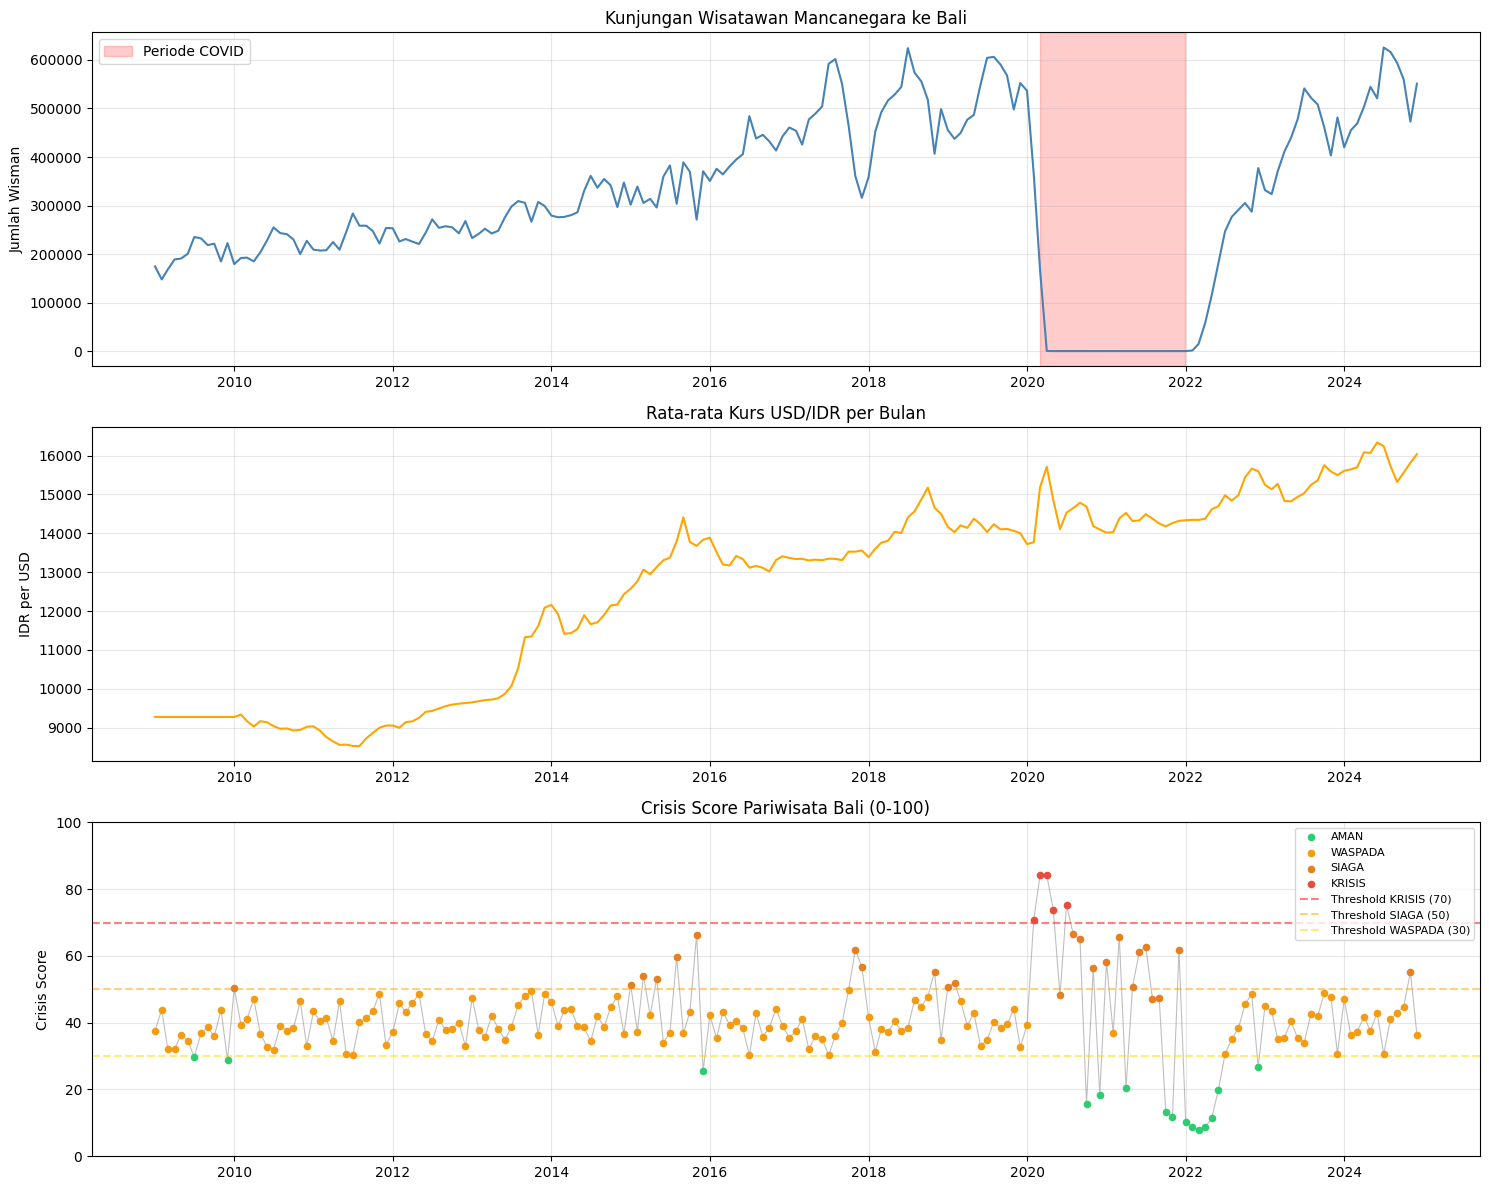

✅ Plot disimpan ke data/processed/crisis_score_timeline.png


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Convert month ke datetime untuk plotting
plot_df = final_df.dropna(subset=['crisis_score_100']).copy()
plot_df['date'] = plot_df['month'].dt.to_timestamp()

# Plot 1: Jumlah Wisman
axes[0].plot(plot_df['date'], plot_df['wisman'], color='steelblue', linewidth=1.5)
axes[0].axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'),
                alpha=0.2, color='red', label='Periode COVID')
axes[0].set_title('Kunjungan Wisatawan Mancanegara ke Bali', fontsize=12)
axes[0].set_ylabel('Jumlah Wisman')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Kurs USD/IDR (jika tersedia)
if 'usd_idr_avg' in plot_df.columns:
    usd_data = plot_df.dropna(subset=['usd_idr_avg'])
    axes[1].plot(usd_data['date'], usd_data['usd_idr_avg'], color='orange', linewidth=1.5)
    axes[1].set_title('Rata-rata Kurs USD/IDR per Bulan', fontsize=12)
    axes[1].set_ylabel('IDR per USD')
    axes[1].grid(alpha=0.3)

# Plot 3: Crisis Score
# Warna berdasarkan level
level_colors = {'AMAN': '#2ecc71', 'WASPADA': '#f39c12', 'SIAGA': '#e67e22', 'KRISIS': '#e74c3c'}
for level, color in level_colors.items():
    mask = plot_df['crisis_level'] == level
    axes[2].scatter(plot_df.loc[mask, 'date'], plot_df.loc[mask, 'crisis_score_100'],
                    c=color, label=level, s=20, zorder=3)

axes[2].plot(plot_df['date'], plot_df['crisis_score_100'], color='gray', linewidth=0.8, alpha=0.5)
axes[2].axhline(70, color='red', linestyle='--', alpha=0.5, label='Threshold KRISIS (70)')
axes[2].axhline(50, color='orange', linestyle='--', alpha=0.5, label='Threshold SIAGA (50)')
axes[2].axhline(30, color='gold', linestyle='--', alpha=0.5, label='Threshold WASPADA (30)')
axes[2].set_title('Crisis Score Pariwisata Bali (0-100)', fontsize=12)
axes[2].set_ylabel('Crisis Score')
axes[2].set_ylim(0, 100)
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/crisis_score_timeline.png', dpi=150)
plt.show()
print('✅ Plot disimpan ke data/processed/crisis_score_timeline.png')

## 7. Simpan Dataset Final

In [11]:
os.makedirs('data/final', exist_ok=True)

# Pilih kolom final untuk dataset output
output_cols = [
    'month',
    # Data mentah
    'wisman', 'wisnus',
    'usd_idr_avg',
    'tpk_bintang', 'tpk_non_bintang', 'tpk_change_mom', 'tpk_ma3', 'inflasi_processed',
    'indonesia_total', 'bali_share_pct',
    'avg_sentiment_global', 'pct_negative_global',
    # Features
    'wisman_growth_mom', 'wisman_growth_yoy',
    'wisman_ma3', 'wisman_ma6',
    'wisman_zscore', 'is_anomaly',
    'usd_volatility_3m', 'usd_change_mom',
    'month_num', 'is_peak_season', 'is_covid_period', 'bali_share_change',
    # Crisis components
    'crisis_component_tourism',
    'crisis_component_economy',
    'crisis_component_sentiment',
    # Crisis score final
    'crisis_score', 'crisis_score_100', 'crisis_level'
]

output_cols = [c for c in output_cols if c in final_df.columns]
final_output = final_df[output_cols].copy()

# ✅ Simpan sebagai CSV (backup) DAN Parquet (untuk dashboard)
final_output.to_csv('data/final/crisis_dataset_final.csv', index=False)

# Konversi month ke string dulu karena Parquet tidak support PeriodIndex
final_parquet = final_output.copy()
final_parquet['month'] = final_parquet['month'].astype(str)
final_parquet.to_parquet('data/final/master_dataset_clean.parquet', index=False)

print(f'✅ CSV disimpan   : data/final/crisis_dataset_final.csv')
print(f'✅ Parquet disimpan: data/final/master_dataset_clean.parquet')
print(f'   Shape: {final_output.shape}')
print(f'   Kolom: {output_cols}')
print()
print('🎯 Dataset FROZEN — siap untuk modeling (NB05) dan dashboard!')

✅ CSV disimpan   : data/final/crisis_dataset_final.csv
✅ Parquet disimpan: data/final/master_dataset_clean.parquet
   Shape: (192, 31)
   Kolom: ['month', 'wisman', 'wisnus', 'usd_idr_avg', 'tpk_bintang', 'tpk_non_bintang', 'tpk_change_mom', 'tpk_ma3', 'inflasi_processed', 'indonesia_total', 'bali_share_pct', 'avg_sentiment_global', 'pct_negative_global', 'wisman_growth_mom', 'wisman_growth_yoy', 'wisman_ma3', 'wisman_ma6', 'wisman_zscore', 'is_anomaly', 'usd_volatility_3m', 'usd_change_mom', 'month_num', 'is_peak_season', 'is_covid_period', 'bali_share_change', 'crisis_component_tourism', 'crisis_component_economy', 'crisis_component_sentiment', 'crisis_score', 'crisis_score_100', 'crisis_level']

🎯 Dataset FROZEN — siap untuk modeling (NB05) dan dashboard!


## 8. Summary & Statistik Akhir

In [12]:
print('=' * 60)
print('RINGKASAN DATASET FINAL — EARLY WARNING SYSTEM BALI')
print('=' * 60)
print(f'Total periode data  : {len(final_output)} bulan')
print(f'Rentang waktu       : {final_output["month"].min()} hingga {final_output["month"].max()}')
print(f'Total fitur         : {len(output_cols) - 2} fitur (+ month dan crisis_level)')
print()
print('Distribusi Level Krisis:')
crisis_dist = final_output['crisis_level'].value_counts()
for level, count in crisis_dist.items():
    emoji = {'AMAN': '🟢', 'WASPADA': '🟡', 'SIAGA': '🟠', 'KRISIS': '🔴'}.get(level, '⚪')
    pct = count / len(final_output) * 100
    print(f'  {emoji} {level}: {count} bulan ({pct:.1f}%)')

print()
print('Statistik Crisis Score:')
cs_stats = final_output['crisis_score_100'].describe()
print(f'  Min   : {cs_stats["min"]:.1f}')
print(f'  Max   : {cs_stats["max"]:.1f}')
print(f'  Mean  : {cs_stats["mean"]:.1f}')
print(f'  Std   : {cs_stats["std"]:.1f}')
print()
print('Langkah selanjutnya:')
print('  → Buka file crisis_dataset_final.csv untuk analisis lanjutan')
print('  → Bangun dashboard Streamlit menggunakan data ini')
print('  → Integrasikan LLM Narrative Engine ke dalam pipeline')

RINGKASAN DATASET FINAL — EARLY WARNING SYSTEM BALI
Total periode data  : 192 bulan
Rentang waktu       : 2009-01 hingga 2024-12
Total fitur         : 29 fitur (+ month dan crisis_level)

Distribusi Level Krisis:
  🟡 WASPADA: 148 bulan (77.1%)
  🟠 SIAGA: 24 bulan (12.5%)
  🟢 AMAN: 15 bulan (7.8%)
  🔴 KRISIS: 5 bulan (2.6%)

Statistik Crisis Score:
  Min   : 8.0
  Max   : 84.2
  Mean  : 40.9
  Std   : 11.9

Langkah selanjutnya:
  → Buka file crisis_dataset_final.csv untuk analisis lanjutan
  → Bangun dashboard Streamlit menggunakan data ini
  → Integrasikan LLM Narrative Engine ke dalam pipeline


---
## 9. Bonus: Heatmap Korelasi Antar Fitur

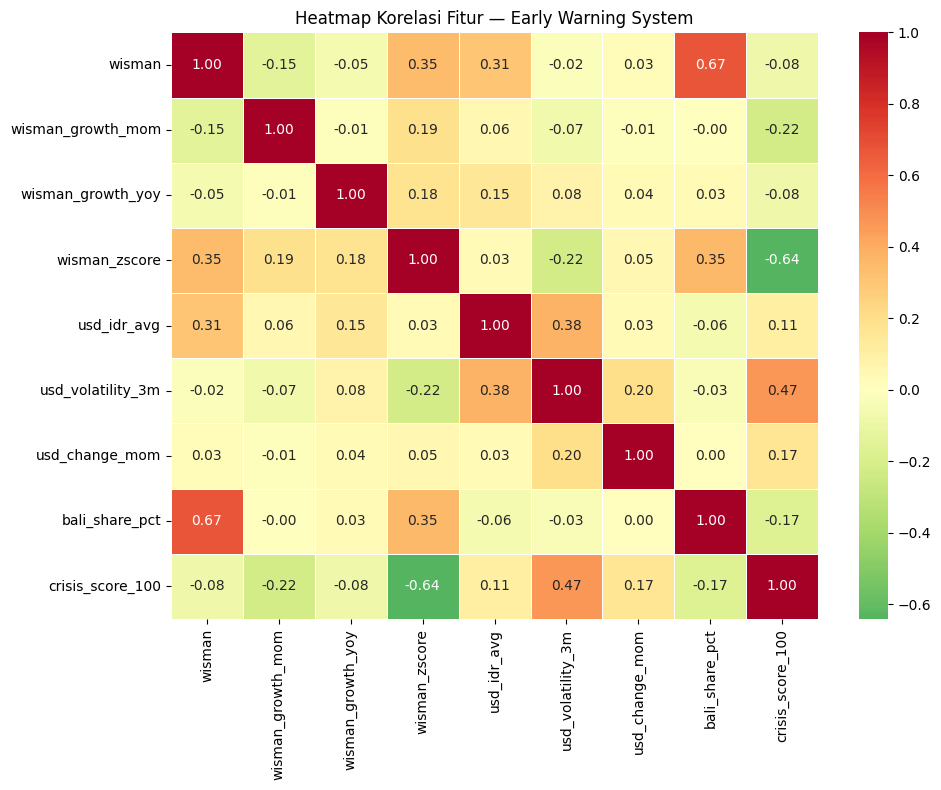

✅ Heatmap disimpan ke data/processed/feature_correlation_heatmap.png


In [13]:
# Heatmap korelasi fitur numerik
numeric_cols = [
    'wisman', 'wisman_growth_mom', 'wisman_growth_yoy', 'wisman_zscore',
    'usd_idr_avg', 'usd_volatility_3m', 'usd_change_mom',
    'bali_share_pct',
    'crisis_score_100'
]
numeric_cols = [c for c in numeric_cols if c in final_output.columns]

corr_matrix = final_output[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5
)
plt.title('Heatmap Korelasi Fitur — Early Warning System', fontsize=12)
plt.tight_layout()
plt.savefig('data/processed/feature_correlation_heatmap.png', dpi=150)
plt.show()
print('✅ Heatmap disimpan ke data/processed/feature_correlation_heatmap.png')